# Inspect and trim the beginning of an eclipse HDF5 light curve

In [1]:
from pathlib import Path
import shutil

import h5py
import matplotlib.pyplot as plt
import numpy as np

try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False

plt.rcParams.update({"figure.figsize": (12, 5), "font.size": 12})

## 1. Choose the input and output files

Use a new output filename. Parent directories will be created automatically. Set `OVERWRITE = True` only if you intentionally want to replace an existing output file.

In [2]:
INPUT_PATH = Path("/home/ssalhi/projects/def-lplevass/ssalhi/ROCKY_WORLDS_REPO/lhs1140b/step1/eclipse4/stage3/S3_2026-06-12_miri_lhs1140_eclipse4_run1/ap5_bg12_30/S3_miri_lhs1140_eclipse4_ap5_bg12_30_SpecData.h5").expanduser()
OUTPUT_PATH = Path("/home/ssalhi/projects/def-lplevass/ssalhi/ROCKY_WORLDS_REPO/lhs1140b/step1/eclipse4/stage3/S3_2026-06-12_miri_lhs1140_eclipse4_run1/ap5_bg12_30/eclipse4_trimmed_SpecData.h5").expanduser()
OVERWRITE = True

# Dataset names used by the Rocky-Worlds pipeline. These may also be paths
# such as 'photometry/aplev' if a future file stores them inside a group.
DATASET_PATHS = {
    "time": "time",
    "flux": "aplev",
    "flux_err": "aperr",
    "centroid_x": "centroid_x",
    "centroid_y": "centroid_y"
    # "full_model": "full_model", 
    # "noise_model": "noise_model"
}

if not INPUT_PATH.is_file():
    raise FileNotFoundError(f"Input HDF5 file not found: {INPUT_PATH}")
if INPUT_PATH.resolve() == OUTPUT_PATH.resolve():
    raise ValueError("INPUT_PATH and OUTPUT_PATH must be different; the source is never modified.")

print(f"Input:  {INPUT_PATH.resolve()}")
print(f"Output: {OUTPUT_PATH.resolve()}")

with h5py.File(INPUT_PATH, "r") as f:
    f.visit(print)

Input:  /lustre06/project/6044613/ssalhi/ROCKY_WORLDS_REPO/lhs1140b/step1/eclipse4/stage3/S3_2026-06-12_miri_lhs1140_eclipse4_run1/ap5_bg12_30/S3_miri_lhs1140_eclipse4_ap5_bg12_30_SpecData.h5
Output: /lustre06/project/6044613/ssalhi/ROCKY_WORLDS_REPO/lhs1140b/step1/eclipse4/stage3/S3_2026-06-12_miri_lhs1140_eclipse4_run1/ap5_bg12_30/eclipse4_trimmed_SpecData.h5
aperr
aplev
betaper
centroid_sx
centroid_sy
centroid_x
centroid_y
medflux
nappix
nskyideal
nskypix
skyerr
skylev
status
time
wave_1d
x
y


## 2. Inspect the file and load the required arrays

In [3]:
def describe_h5(path):
    rows = []
    with h5py.File(path, "r") as h5:
        def visitor(name, obj):
            if isinstance(obj, h5py.Dataset):
                rows.append((name, obj.shape, str(obj.dtype)))
        h5.visititems(visitor)
    print(f"{'dataset':45s} {'shape':20s} dtype")
    print("-" * 85)
    for name, shape, dtype in rows:
        print(f"{name:45s} {str(shape):20s} {dtype}")
    return rows

h5_inventory = describe_h5(INPUT_PATH)

with h5py.File(INPUT_PATH, "r") as h5:
    missing = [path for path in DATASET_PATHS.values() if path not in h5]
    if missing:
        raise KeyError(f"Required dataset(s) not found: {missing}")
    arrays = {key: np.asarray(h5[path]) for key, path in DATASET_PATHS.items()}

n_integrations = arrays["time"].shape[0]
bad_lengths = {key: value.shape for key, value in arrays.items() if value.ndim == 0 or value.shape[0] != n_integrations}
if bad_lengths:
    raise ValueError(f"Required arrays do not share the time-axis length {n_integrations}: {bad_lengths}")

time = np.asarray(arrays["time"], dtype=float)
flux = np.asarray(arrays["flux"], dtype=float)
flux_err = np.asarray(arrays["flux_err"], dtype=float)
centroid_x = np.asarray(arrays["centroid_x"], dtype=float)
centroid_y = np.asarray(arrays["centroid_y"], dtype=float)
# full_model = np.asarray(arrays["full_model"], dtype=float)
# noise_model = np.asarray(arrays["noise_model"], dtype=float)
time_hours = (time - time[0]) * 24.0

print(f"Loaded {n_integrations:,} integrations.")

dataset                                       shape                dtype
-------------------------------------------------------------------------------------
aperr                                         (3356,)              float64
aplev                                         (3356,)              float64
betaper                                       (3356,)              float64
centroid_sx                                   (3356,)              float64
centroid_sy                                   (3356,)              float64
centroid_x                                    (3356,)              float64
centroid_y                                    (3356,)              float64
medflux                                       (254, 254)           float32
nappix                                        (3356,)              float64
nskyideal                                     (3356,)              float64
nskypix                                       (3356,)              float64
skyerr          

## 3. Preview a proposed cut

The selected index is the **first point retained**. Red points will be removed and black points will remain. The lower panels help determine whether centroid settling occurs at the same time as the flux ramp.

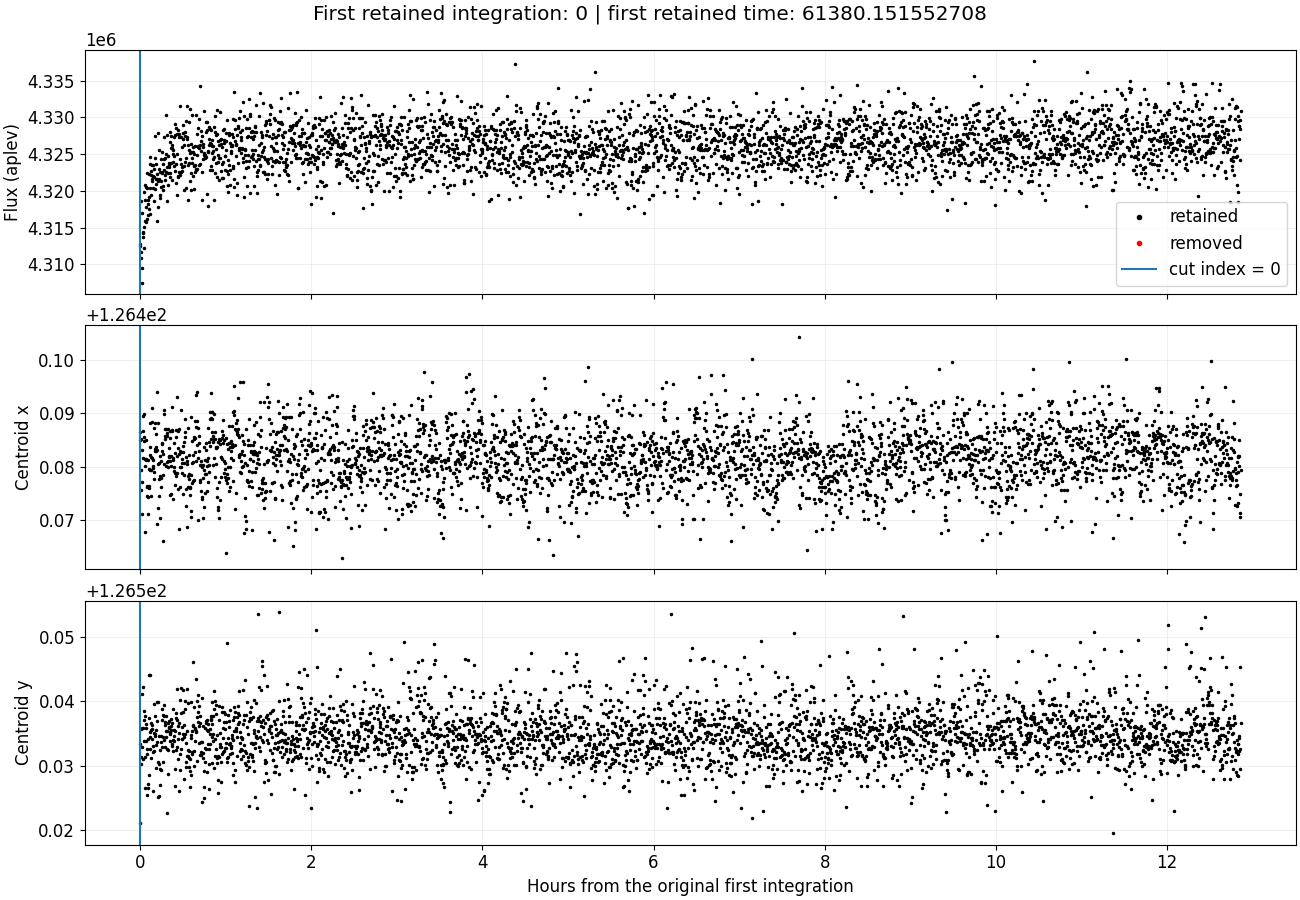

In [4]:
%matplotlib widget
def plot_cut_preview(cut_index, zoom_points=None):
    cut_index = int(cut_index)
    if not 0 <= cut_index < n_integrations:
        raise ValueError(f"cut_index must be between 0 and {n_integrations - 1}")

    stop = n_integrations if zoom_points is None else min(n_integrations, int(zoom_points))
    shown = np.arange(stop)
    removed = shown < cut_index
    retained = ~removed

    fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True, constrained_layout=True)
    series = [(flux, "Flux (aplev)"), (centroid_x, "Centroid x"), (centroid_y, "Centroid y")]
    for axis, (values, ylabel) in zip(axes, series):
        axis.plot(time_hours[shown][retained], values[shown][retained], "k.", ms=3, label="retained")
        axis.plot(time_hours[shown][removed], values[shown][removed], "r.", ms=3, label="removed")
        # axis.plot(time_hours, full_model, "b-", label="full model")
        # axis.plot(time_hours, noise_model, "g-", label="noise model")
        axis.axvline(time_hours[cut_index], color="tab:blue", lw=1.5, label=f"cut index = {cut_index}")
        axis.set_ylabel(ylabel)
        axis.grid(alpha=0.2)
    axes[0].legend(loc="best", markerscale=2)
    axes[-1].set_xlabel("Hours from the original first integration")
    fig.suptitle(f"First retained integration: {cut_index} | first retained time: {time[cut_index]:.9f}")
    plt.show()

# Start by concentrating on the beginning of the observation. Increase this
# value or use None to show the entire light curve.
ZOOM_POINTS = n_integrations # min(1000, n_integrations)
plot_cut_preview(cut_index=0, zoom_points=None)

In [ ]:
# Optional interactive selector. Moving the slider redraws the preview.
# If ipywidgets is unavailable, set CUT_INDEX manually in the next cell.
if HAS_WIDGETS:
    cut_slider = widgets.IntSlider(
        value=0, min=0, max=n_integrations - 1, step=1,
        description="Cut index:", continuous_update=False,
        layout=widgets.Layout(width="85%"),
    )
    zoom_box = widgets.IntText(value=ZOOM_POINTS, description="Plot points:")
    output = widgets.interactive_output(
        plot_cut_preview, {"cut_index": cut_slider, "zoom_points": zoom_box}
    )
    display(widgets.VBox([cut_slider, zoom_box]), output)
else:
    print("ipywidgets is not installed; use the manual CUT_INDEX cell below.")

Output()

## 4. Confirm the cut index

Run this cell after choosing the index. If you used the slider, its current value is copied automatically. Otherwise, replace `0` with your chosen index.

Removing indices 0 through 356.
Keeping indices 357 through 3355.
Output will contain 2,999 integrations.


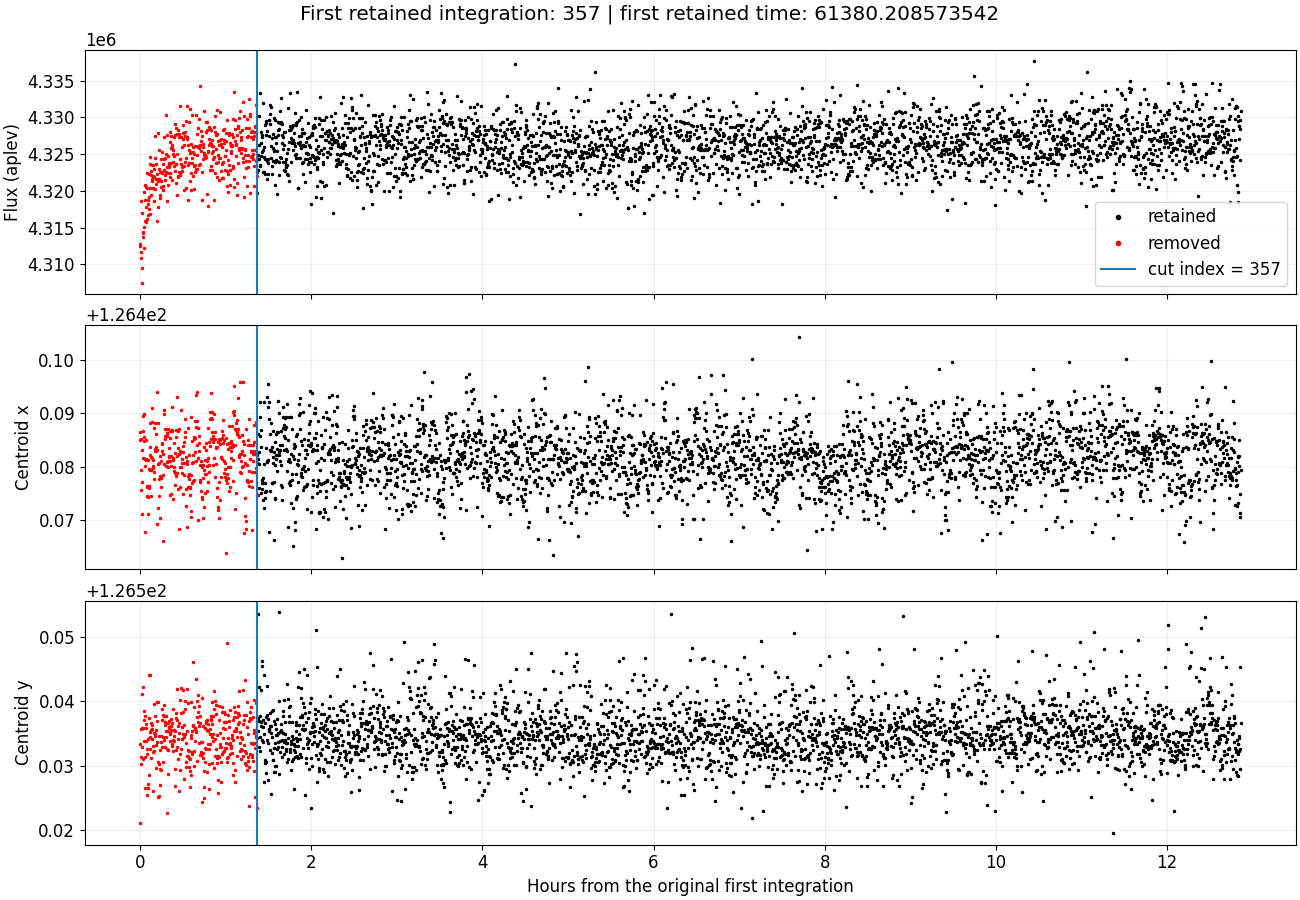

In [6]:
CUT_INDEX = int(cut_slider.value) if HAS_WIDGETS else 0

if not 0 <= CUT_INDEX < n_integrations:
    raise ValueError(f"CUT_INDEX must be between 0 and {n_integrations - 1}")

print(f"Removing indices 0 through {CUT_INDEX - 1}.")
print(f"Keeping indices {CUT_INDEX} through {n_integrations - 1}.")
print(f"Output will contain {n_integrations - CUT_INDEX:,} integrations.")
plot_cut_preview(CUT_INDEX, zoom_points=ZOOM_POINTS)

## 5. Identify every integration-aligned dataset

By default, the notebook trims every non-scalar dataset whose first dimension equals the original time length. This keeps arrays such as `status`, `medflux`, or other integration diagnostics synchronized with `time`. Review the printed list carefully. Set `TRIM_ALL_TIME_ALIGNED = False` to trim only the five required pipeline arrays.

In [7]:
TRIM_ALL_TIME_ALIGNED = True
required_paths = set(DATASET_PATHS.values())

with h5py.File(INPUT_PATH, "r") as h5:
    matching_paths = []
    def find_matching(name, obj):
        if isinstance(obj, h5py.Dataset) and obj.ndim > 0 and obj.shape[0] == n_integrations:
            matching_paths.append(name)
    h5.visititems(find_matching)

datasets_to_trim = sorted(set(matching_paths) if TRIM_ALL_TIME_ALIGNED else required_paths)
missing_required = sorted(required_paths - set(datasets_to_trim))
if missing_required:
    raise RuntimeError(f"Required datasets were excluded unexpectedly: {missing_required}")

print("Datasets that will be trimmed along axis 0:")
for path in datasets_to_trim:
    marker = " (required)" if path in required_paths else ""
    print(f"  - {path}{marker}")

Datasets that will be trimmed along axis 0:
  - aperr (required)
  - aplev (required)
  - betaper
  - centroid_sx
  - centroid_sy
  - centroid_x (required)
  - centroid_y (required)
  - nappix
  - nskyideal
  - nskypix
  - skyerr
  - skylev
  - status
  - time (required)


## 6. Save the trimmed HDF5 file

This cell refuses to overwrite an existing output unless `OVERWRITE = True`. It copies the complete input file, then replaces the listed datasets while preserving their attributes and storage options.

In [8]:
def dataset_creation_options(dataset, new_shape):
    options = {}
    if dataset.chunks is not None:
        options["chunks"] = tuple(min(chunk, size) for chunk, size in zip(dataset.chunks, new_shape))
    if dataset.compression is not None:
        options["compression"] = dataset.compression
        options["compression_opts"] = dataset.compression_opts
    if dataset.shuffle:
        options["shuffle"] = True
    if dataset.fletcher32:
        options["fletcher32"] = True
    if dataset.scaleoffset is not None:
        options["scaleoffset"] = dataset.scaleoffset
    if dataset.fillvalue is not None:
        options["fillvalue"] = dataset.fillvalue
    if dataset.maxshape is not None:
        options["maxshape"] = tuple(
            None if maximum is None else max(int(maximum), int(size))
            for maximum, size in zip(dataset.maxshape, new_shape)
        )
    return options

def replace_with_trimmed_dataset(h5, dataset_path, cut_index):
    original = h5[dataset_path]
    trimmed = original[cut_index:, ...]
    attributes = dict(original.attrs.items())
    dtype = original.dtype
    options = dataset_creation_options(original, trimmed.shape)
    parent = original.parent
    name = original.name.rsplit("/", 1)[-1]
    del parent[name]
    replacement = parent.create_dataset(name, data=trimmed, dtype=dtype, **options)
    for key, value in attributes.items():
        replacement.attrs[key] = value

def save_trimmed_h5(input_path, output_path, cut_index, dataset_paths, overwrite=False):
    input_path = Path(input_path).expanduser().resolve()
    output_path = Path(output_path).expanduser().resolve()
    if input_path == output_path:
        raise ValueError("Input and output paths must be different.")
    if output_path.exists() and not overwrite:
        raise FileExistsError(f"Output already exists: {output_path}. Set OVERWRITE=True to replace it.")
    output_path.parent.mkdir(parents=True, exist_ok=True)
    if output_path.exists():
        output_path.unlink()
    shutil.copy2(input_path, output_path)
    try:
        with h5py.File(output_path, "r+") as h5:
            for dataset_path in dataset_paths:
                replace_with_trimmed_dataset(h5, dataset_path, cut_index)
    except Exception:
        if output_path.exists():
            output_path.unlink()
        raise
    return output_path

saved_path = save_trimmed_h5(
    INPUT_PATH, OUTPUT_PATH, CUT_INDEX, datasets_to_trim, overwrite=OVERWRITE
)
print(f"Saved trimmed file: {saved_path}")

Saved trimmed file: /lustre06/project/6044613/ssalhi/ROCKY_WORLDS_REPO/lhs1140b/step1/eclipse4/stage3/S3_2026-06-12_miri_lhs1140_eclipse4_run1/ap5_bg12_30/eclipse4_trimmed_SpecData.h5
